In [101]:
import math
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler

import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## Конфігурація

In [ ]:
FEATURES         = ['cpu', 'rps']   # RAM прибрано: CV=1.34% у EDA → чистий шум
TARGET_FEATURE   = 'cpu'
WINDOW_SIZE      = 20    # кроків × 5с = 100с контексту; = MODEL_INPUT_STEPS у продакшні
FORECAST_HORIZON = 6     # 6 × 5с = 30с вперед

# Архітектура
LAYER_SIZE    = 64
DROPOUT_RATE  = 0.35    # збільшено з 0.2 → менше overfitting
L2_REG        = 1e-4    # L2 regularization на GRU weights
LEARNING_RATE = 5e-4
BATCH_SIZE    = 32
MAX_EPOCHS    = 150
PATIENCE      = 20

# Preprocessing
CPU_MIN_THRESHOLD = 0.01   # cores = 10m, фільтр idle-стану
PCT_CLIP          = 20.0   # обрізаємо outlier targets зверху

# Safety factor при інференсі: MSE вчить умовне середнє → множимо на buffer
SAFETY_FACTOR = 1.5   # збільшено з 1.25 → менше underprediction

N_FEAT = len(FEATURES)   # зручна константа для індексування масивів

print(f"Window:   {WINDOW_SIZE} steps × 5s = {WINDOW_SIZE*5}s")
print(f"Horizon:  {FORECAST_HORIZON} steps × 5s = {FORECAST_HORIZON*5}s")
print(f"Features: {FEATURES}  (n={N_FEAT})")
print(f"Model:    GRU({LAYER_SIZE}), dropout={DROPOUT_RATE}, L2={L2_REG}, lr={LEARNING_RATE}")
print(f"Safety:   ×{SAFETY_FACTOR} при інференсі")

Window:   20 steps × 5s = 100s
Horizon:  6 steps × 5s = 30s
Features: ['cpu', 'rps']  (n=2)
Model:    GRU(64), dropout=0.35, L2=0.0001, lr=0.0005
Safety:   ×1.5 при інференсі


## Завантаження даних

**Два незалежні датасети:**
- `TRAIN_FILE` — новий, зібраний для навчання (кожен сценарій 2-3 рази)
- `VAL_FILE`   — поточний, зібраний раніше, модель його ніколи не бачила

Скейлери навчаються **тільки на train** → чиста оцінка узагальнення на val.

In [103]:
TRAIN_FILE = "./raw_data/data-1774627968260.csv"   # 18 сценаріїв (3×6), 222 хв, 1717 активних рядків
VAL_FILE   = "./raw_data/data-1774610506409.csv"   # held-out: 5 сценаріїв, зібраний окремо

CPU_MIN_THRESHOLD = 0.01  # cores = 10m — фільтр idle-стану між сценаріями

def load_locust(path):
    df = pd.read_csv(path, parse_dates=['ts'])
    df = df.sort_values('ts').reset_index(drop=True)
    df = df.rename(columns={'input_cpu': 'cpu', 'input_ram': 'ram', 'input_rps': 'rps'})
    df = df[['cpu', 'ram', 'rps']].dropna()
    df = df[df['cpu'] > CPU_MIN_THRESHOLD].reset_index(drop=True)
    return df

df_train = load_locust(TRAIN_FILE)
df_val   = load_locust(VAL_FILE)

print(f"Train: {len(df_train)} рядків  (18 сценаріїв, 3×6 повторів)")
print(f"Val:   {len(df_val)} рядків  (held-out, 5 сценаріїв)")

Train: 1717 рядків  (18 сценаріїв, 3×6 повторів)
Val:   358 рядків  (held-out, 5 сценаріїв)


## Percentage change + формування вікон

In [104]:
EPS = 1e-6

def transform_to_pct_change(df, features, target_col, horizon, pct_clip=None):
    """
    X: відносна зміна між кроками для кожної фічі
    y: max(future peak growth, 0) / current_cpu  — тільки зростання, спади = 0
       Для автоскейлера спади нерелевантні: модель вчиться тільки "наскільки більше потрібно"

    pct_clip: обрізає великі outliers зверху (наприклад ramp з 10m → 1.5c = 149x)

    Колонки виходу: 0:N_FEAT = features, N_FEAT = target, N_FEAT+1 = current_cpu
    Зворотнє перетворення: pred_peak_cores = current_cpu * (1 + pred_pct)
    """
    n = len(features)
    out = pd.DataFrame()
    for f in features:
        out[f'{f}_step'] = (df[f] - df[f].shift(1)) / (df[f].shift(1) + EPS)

    future_peak = df[target_col].rolling(window=horizon).max().shift(-horizon)
    out[f'{target_col}_target'] = (future_peak - df[target_col]) / (df[target_col] + EPS)

    # Clip: знизу 0 (не вчимось передбачати спади), зверху pct_clip (прибираємо outliers)
    lo = 0.0
    hi = pct_clip if pct_clip is not None else float('inf')
    out[f'{target_col}_target'] = out[f'{target_col}_target'].clip(lo, hi)

    out['current_cpu'] = df[target_col].values
    return out.dropna().values  # shape: (N, n+2)


def create_sequences(X_data, y_data, window_size):
    X, y = [], []
    for i in range(len(X_data) - window_size + 1):
        X.append(X_data[i : i + window_size])
        y.append(y_data[i + window_size - 1])
    return np.array(X), np.array(y)


raw_train = transform_to_pct_change(df_train, FEATURES, TARGET_FEATURE, FORECAST_HORIZON, PCT_CLIP)
raw_val   = transform_to_pct_change(df_val,   FEATURES, TARGET_FEATURE, FORECAST_HORIZON, PCT_CLIP)

n = N_FEAT
print(f"Train: {raw_train.shape}  target: max={raw_train[:,n].max():.2f}  mean={raw_train[:,n].mean():.2f}  std={raw_train[:,n].std():.2f}")
print(f"Val:   {raw_val.shape}  target: max={raw_val[:,n].max():.2f}  mean={raw_val[:,n].mean():.2f}  std={raw_val[:,n].std():.2f}")

Train: (1710, 4)  target: max=20.00  mean=2.32  std=4.88
Val:   (351, 4)  target: max=20.00  mean=3.42  std=5.93


## Масштабування та нарізка вікон

In [105]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Скейлери навчаються ТІЛЬКИ на train — без витоку даних у val
# Колонки: 0:N_FEAT = features, N_FEAT = target, N_FEAT+1 = current_cpu
X_train_sc = scaler_X.fit_transform(raw_train[:, :N_FEAT])
y_train_sc = scaler_y.fit_transform(raw_train[:, N_FEAT:N_FEAT+1])

X_val_sc = scaler_X.transform(raw_val[:, :N_FEAT])
y_val_sc = scaler_y.transform(raw_val[:, N_FEAT:N_FEAT+1])

X_train, y_train = create_sequences(X_train_sc, y_train_sc, WINDOW_SIZE)
X_val,   y_val   = create_sequences(X_val_sc,   y_val_sc,   WINDOW_SIZE)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  y_val:   {y_val.shape}")

X_train: (1691, 20, 2)  y_train: (1691, 1)
X_val:   (332, 20, 2)  y_val:   (332, 1)


## Побудова та навчання моделі

In [106]:
def build_model(window_size, n_features, layer_size, dropout_rate, lr, l2_reg=0.0):
    model = Sequential([
        Input(shape=(window_size, n_features)),
        GRU(
            units=layer_size,
            kernel_regularizer=l2(l2_reg),
            recurrent_regularizer=l2(l2_reg),
        ),
        Dropout(dropout_rate),
        Dense(1),
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr, clipnorm=1.0),
        loss='mse',
        metrics=['mae'],
    )
    return model


model = build_model(
    window_size=WINDOW_SIZE,
    n_features=N_FEAT,
    layer_size=LAYER_SIZE,
    dropout_rate=DROPOUT_RATE,
    lr=LEARNING_RATE,
    l2_reg=L2_REG,
)
model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_18 (GRU)                    │ (None, 64)             │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,121 (51.25 KB)

 Trainable params: 13,121 (51.25 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.9414 - mae: 0.6536 - val_loss: 1.2928 - val_mae: 0.7105 - learning_rate: 5.0000e-04
Epoch 2/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9143 - mae: 0.6327 - val_loss: 1.2797 - val_mae: 0.7030 - learning_rate: 5.0000e-04
Epoch 3/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8953 - mae: 0.6204 - val_loss: 1.2622 - val_mae: 0.7004 - learning_rate: 5.0000e-04
Epoch 4/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8647 - mae: 0.6030 - val_loss: 1.1719 - val_mae: 0.6906 - learning_rate: 5.0000e-04
Epoch 5/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8065 - mae: 0.5707 - val_loss: 1.0655 - val_mae: 0.6658 - learning_rate: 5.0000e-04
Epoch 6/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7842 - mae: 0.5610 - val_loss: 1.0310 - val_mae: 0.6428 - learning_rate: 5.0000e-04
Epoch 7/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7764 - mae: 0.5541 - val_loss: 0.9922 - val_mae: 0.6414 - learning_r

## Криві навчання

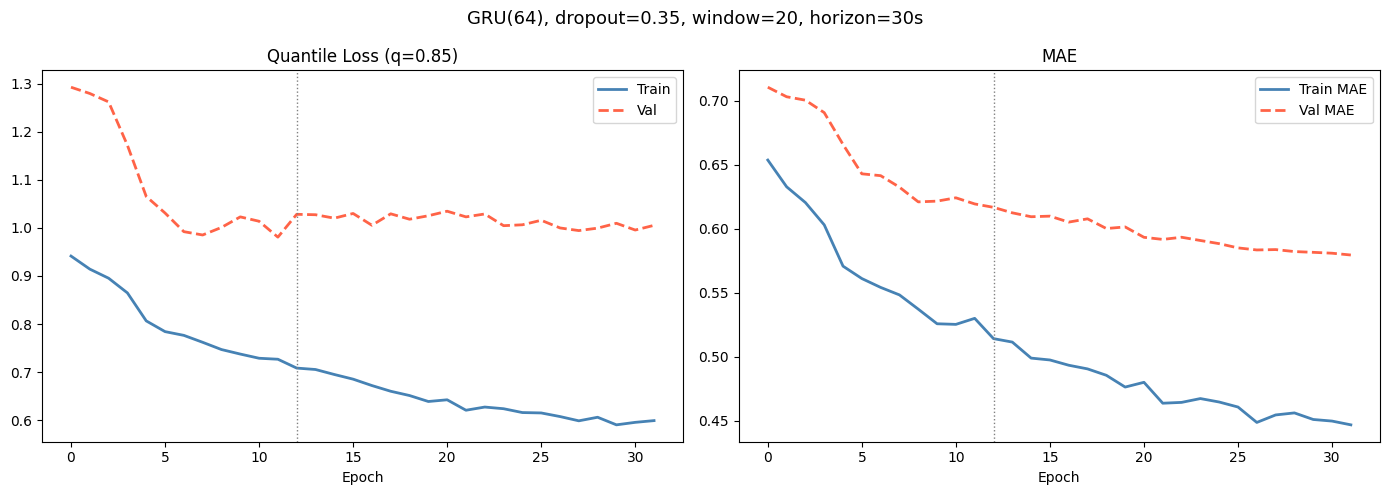

Best epoch: 12  |  Best val_loss: 0.98076


In [108]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train', color='steelblue',  linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val',   color='tomato', linestyle='--', linewidth=2)
axes[0].set_title('Quantile Loss (q=0.85)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE', color='steelblue',  linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='tomato', linestyle='--', linewidth=2)
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()

best_epoch = np.argmin(history.history['val_loss']) + 1
best_val   = min(history.history['val_loss'])
for ax in axes:
    ax.axvline(best_epoch, color='gray', linestyle=':', linewidth=1, label=f'best epoch={best_epoch}')

plt.suptitle(f'GRU({LAYER_SIZE}), dropout={DROPOUT_RATE}, window={WINDOW_SIZE}, horizon={FORECAST_HORIZON*5}s', fontsize=13)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best epoch: {best_epoch}  |  Best val_loss: {best_val:.5f}")

## Збереження артефактів

Фінальна модель тренується на **100% даних** з кількістю епох = best_epoch з валідації.

In [109]:
prod_scaler_X = StandardScaler()
prod_scaler_y = StandardScaler()

X_full_sc = prod_scaler_X.fit_transform(raw_train[:, :N_FEAT])
y_full_sc = prod_scaler_y.fit_transform(raw_train[:, N_FEAT:N_FEAT+1])
X_full, y_full = create_sequences(X_full_sc, y_full_sc, WINDOW_SIZE)

final_model = build_model(
    window_size=WINDOW_SIZE,
    n_features=N_FEAT,
    layer_size=LAYER_SIZE,
    dropout_rate=DROPOUT_RATE,
    lr=LEARNING_RATE,
    l2_reg=L2_REG,
)

final_model.fit(
    X_full, y_full,
    epochs=best_epoch,
    batch_size=BATCH_SIZE,
    verbose=1,
)

final_model.save('production_k8s_autoscaler_sniper.keras')
joblib.dump(prod_scaler_X, 'production_scaler_X.joblib')
joblib.dump(prod_scaler_y, 'production_scaler_y.joblib')

model_config = {
    'window_size':      WINDOW_SIZE,
    'forecast_horizon': FORECAST_HORIZON,
    'features':         FEATURES,
    'model_type':       'gru',
    'layer_size':       LAYER_SIZE,
    'dropout':          DROPOUT_RATE,
    'l2_reg':           L2_REG,
    'pct_clip':         PCT_CLIP,
    'safety_factor':    SAFETY_FACTOR,
}
with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print('Збережено:')
print('  production_k8s_autoscaler_sniper.keras')
print('  production_scaler_X.joblib / production_scaler_y.joblib')
print('  model_config.json')
print(f'\n{json.dumps(model_config, indent=2)}')

Epoch 1/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.9428 - mae: 0.6576
Epoch 2/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9172 - mae: 0.6280
Epoch 3/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8952 - mae: 0.6141
Epoch 4/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8622 - mae: 0.5979
Epoch 5/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8065 - mae: 0.5732
Epoch 6/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7837 - mae: 0.5609
Epoch 7/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7673 - mae: 0.5615
Epoch 8/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7520 - mae: 0.5502
Epoch 9/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7442 - mae: 0.5470
Epoch 10/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7354 - mae: 0.5429
Epoch 11/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7129 - mae: 0.5225
Epoch 12/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7099 - mae: 0.5249
Збережено:
  production_k8s_autoscaler_sniper.ker

## Оцінка на валідаційному наборі (симуляція реального часу)

In [110]:
# Колонки raw_val: 0:N_FEAT = features, N_FEAT = target, N_FEAT+1 = current_cpu
current_cpu_val = raw_val[WINDOW_SIZE - 1:, N_FEAT + 1]  # (N_val_windows,)

X_eval_sc = scaler_X.transform(raw_val[:, :N_FEAT])
y_eval_sc = scaler_y.transform(raw_val[:, N_FEAT:N_FEAT+1])
X_eval, y_eval_sc_seq = create_sequences(X_eval_sc, y_eval_sc, WINDOW_SIZE)

y_pred_sc = model.predict(X_eval, verbose=0)

# Інверсія в pct_change простір
y_pred_pct = scaler_y.inverse_transform(y_pred_sc).flatten()
y_true_pct = scaler_y.inverse_transform(y_eval_sc_seq.reshape(-1, 1)).flatten()

# Реконструкція абсолютних пікових значень CPU (cores → millicores)
actual_peak_m = current_cpu_val * (1 + y_true_pct) * 1000
pred_peak_m   = current_cpu_val * (1 + y_pred_pct) * SAFETY_FACTOR * 1000

mae_m  = np.mean(np.abs(actual_peak_m - pred_peak_m))
rmse_m = np.sqrt(np.mean((actual_peak_m - pred_peak_m) ** 2))
bias_m = np.mean(pred_peak_m - actual_peak_m)
underpred_pct = np.mean(pred_peak_m < actual_peak_m) * 100

print(f"Метрики на val (абсолютні піки CPU, з safety ×{SAFETY_FACTOR}):")
print(f"  MAE:       {mae_m:.1f} m")
print(f"  RMSE:      {rmse_m:.1f} m")
print(f"  Bias:      {bias_m:+.1f} m  ({'завищує' if bias_m > 0 else 'занижує'})")
print(f"  Underpred: {underpred_pct:.1f}%  (ціль: < 20%)")

Метрики на val (абсолютні піки CPU, з safety ×1.5):
  MAE:       1245.0 m
  RMSE:      1964.2 m
  Bias:      +922.7 m  (завищує)
  Underpred: 25.3%  (ціль: < 20%)


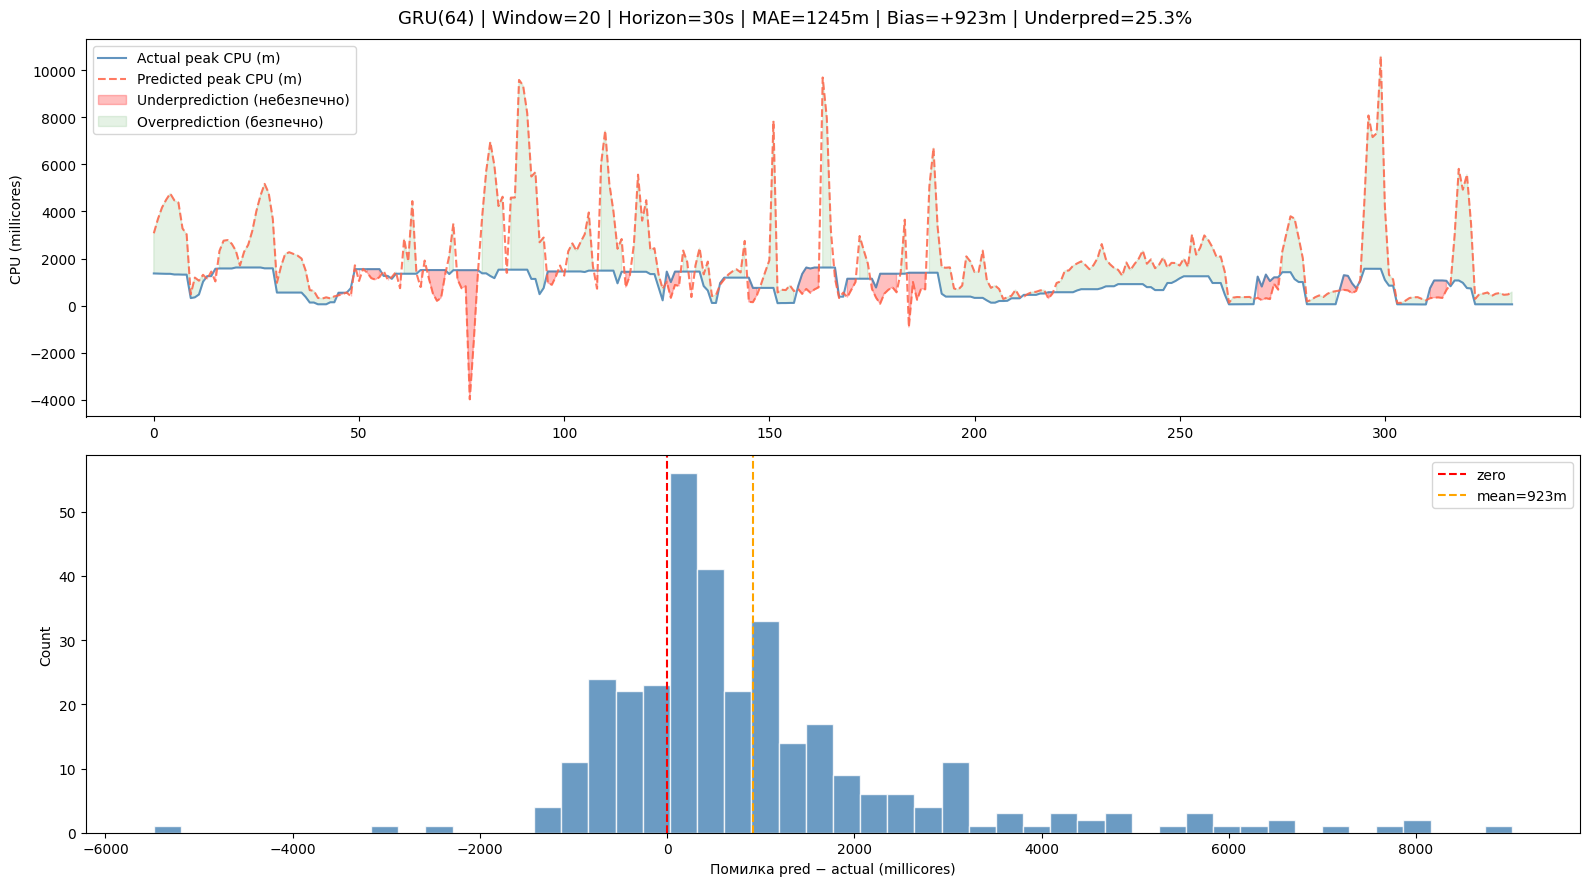

In [111]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle(
    f'GRU({LAYER_SIZE}) | Window={WINDOW_SIZE} | Horizon={FORECAST_HORIZON*5}s | '
    f'MAE={mae_m:.0f}m | Bias={bias_m:+.0f}m | Underpred={underpred_pct:.1f}%',
    fontsize=13
)

idx = np.arange(len(actual_peak_m))
axes[0].plot(idx, actual_peak_m, label='Actual peak CPU (m)',    color='steelblue',  linewidth=1.5, alpha=0.85)
axes[0].plot(idx, pred_peak_m,   label='Predicted peak CPU (m)', color='tomato', linestyle='--', linewidth=1.5, alpha=0.85)
axes[0].fill_between(idx, actual_peak_m, pred_peak_m,
    where=(pred_peak_m < actual_peak_m), alpha=0.25, color='red',   label='Underprediction (небезпечно)')
axes[0].fill_between(idx, actual_peak_m, pred_peak_m,
    where=(pred_peak_m >= actual_peak_m), alpha=0.1, color='green', label='Overprediction (безпечно)')
axes[0].set_ylabel('CPU (millicores)')
axes[0].legend(loc='upper left')

# Гістограма помилок в millicores
err_m = pred_peak_m - actual_peak_m
axes[1].hist(err_m, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0,           color='red',    linestyle='--', linewidth=1.5, label='zero')
axes[1].axvline(err_m.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'mean={err_m.mean():.0f}m')
axes[1].set_xlabel('Помилка pred − actual (millicores)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('inference_simulation.png', dpi=150, bbox_inches='tight')
plt.show()